---
title: Dataset Construction
date: 09/2025
authors:
  - name: James Butler
    affiliations: ucb
  - name: Michelle Maclennan
    affiliation: bas
  - name: Fernando Pérez
    affiliation: ucb
  - name: Jon McAuliffe
    affiliation: ucb
affiliations:
  - id: ucb
    institution: University of California Berkeley
    ror: https://ror.org/01an7q238
    department: Statistics
  - id: bas
    institution: British Antarctic Survey
    ror: https://ror.org/01rhff309
---

This notebook demonstrates some of our software workflows that can be used to construct tabular datasets of Antarctic AR events, including MERRA-2 streaming.

:::{attention}
If running the streaming workflows on CryoCloud, make sure to choose a server with enough RAM, as well as CPUs for parallelization. The RAM used by this notebook should not exceed 15GB at any point during the streaming loop. We ran this notebook on CryoCloud's 29GB server, which has ~4 CPUs available at all times.
:::

## Setup

First, we'll load up any packages and modules we might need.

In [1]:
# load external packages
import os
import pandas as pd
import xarray as xr
from pathlib import Path
import earthaccess
import ray
from tqdm import tqdm
from huggingface_hub import login, HfApi
import logging
import sys

In [2]:
# load artools
import artools
from artools.loading_utils import load_ais, load_cell_areas, EarthdataGatekeeper, load_catalog
from artools.display_utils import display_catalog
from artools.attribute_utils import *
from artools.compute_attributes_streaming import *

/home/jovyan/antarctic_AR_dataset/notebooks


In [3]:
login()

Next, let's load up the catalog. We provide a catalog of the first 250 storms in `subset_storms.h5`.

In [4]:
# load the catalog
storms = load_catalog('epsspace0.5_epstime12_minpts5_nreppts10_seed12345.h5')
# take only those that are landfalling
storms = storms[storms.is_landfalling]

Finally, we load up a mask of grid cells for Antarctica, as well as a mapping of grid cell to cell area.

In [5]:
ais_mask = load_ais()
cell_areas = load_cell_areas()

## Catalog Overview

Before we get started with the masking workflow, we can first take a quick look at the catalog. The catalog is a clustering of AR pixels identified in the [Wille (2021) catalog](https://doi.org/10.5281/zenodo.4009663), which takes an Eulerian approach to identifying atmoshperic rivers.

,data_array,is_landfalling
cluster,,
1,,True
4,,True
5,,True
6,,True
11,,True

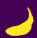
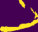

In [6]:
display_catalog(storms, 5)

The `storms` object is a `pandas.DataFrame`, with rows corresponding to different identified AR storm events that made landfall. The `data_array` column contains binary-valued `xarray.DataArray` masks of the full spatiotemporal footprint of the storm. Note, we must use the `display_catalog` function from our local `display_utils` module to view the dataframe. Otherwise, if one attempts to print the dataframe as usual, the `data_array` column will be filled with string representations of the masks which (1) take forever to render and (2) are unpleasant to look at.

In [7]:
storms.loc[1].data_array

<xarray.DataArray 'clust' (time: 15, lat: 72, lon: 71)> Size: 77kB
array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
...
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(15, 72, 71), dtype=int8)
Coordinates:
  * time     (time) datetime64[ns] 120B 1980-01-02 ... 1980-01-03T18:00:00
  * lat      (lat) float64 576B -74.5 -74.0 -73.5 -73.0 ... -40.0 -39.5 -39.0
  * lon      (lon) float64 568B -119.4 -118.8 -118.1 ... -76.88 -76.25 -75.62

Organizing the catalog in this way means we can appeal to `pandas` very powerful and compact API to compute relevant storm quantities.

## Filling in Storm Attributes and Impacts

Now let's put these masks to good use and start grabbing interesting quantities associated with each storm. There are two kinds of quantities we can compute, ones which need reanalysis data (geographic attributes, when and where, etc.) and ones which don't (atmospheric quantities). We'll start with computing quantities that don't yet require reanalysis data and finish with a fully cloud-based workflow to compute quantities that do require reanalysis.

### Geographic Quantities

Let's start with computing geographic attributes of each landfalling storm. This includes the following quantities:
+ `max_area`: the largest areal extent of the storm over its complete lifetime
+ `mean_landfalling_area`: the average landfalling areal extent of the storm
+ `cumulative_landfalling_area`: the cumulative time x space the storm spent over the ice sheet
+ `duration`: how long did it last
+ `start_date`: when did the storm first appear
+ `end_date`: when did it dissipate
+ `max_south_extent`: how far south did it go, in degrees latitude?
+ `region`: the region of Antarctica it made landfall in (either `West`, `East 1`, or `East 2`)

Helper functions to compute each of these attributes given a storm's `xarray.DataArray` can be found in the `attributes_utils` module.

In [8]:
storms['max_area'] = storms['data_array'].apply(lambda x: compute_max_area(x, cell_areas)).astype(int)
storms['mean_landfalling_area'] = storms['data_array'].apply(lambda x: compute_mean_area(x, cell_areas, ais_mask)).astype(int)
storms['cumulative_landfalling_area'] = storms['data_array'].apply(lambda x: compute_cumulative_spacetime(x, cell_areas, ais_mask)).astype(int)
storms['duration'] = storms['data_array'].apply(compute_duration)
storms['start_date'] = storms['data_array'].apply(add_start_date)
storms['end_date'] = storms['data_array'].apply(add_end_date)
storms['max_south_extent'] = storms['data_array'].apply(compute_max_southward_extent)

# regions defined by ranges of longitudes
region_defs = {'West': [-150, -30], 
               'East 1': [-30, 75],
               'East 2': [75, -150]}
# use helper function to divide full AIS mask into sectors corresponding to each region
region_masks = find_region_masks(region_defs, ais_mask)
storms['region'] = storms['data_array'].apply(lambda x: find_landfalling_region(x, cell_areas, region_masks))

Let's take a look at what we were able to create.

,data_array,is_landfalling,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,region
cluster,,,,,,,,,,
1,,True,1906980,14234,26690,45,1980-01-02 00:00:00,1980-01-03 18:00:00,-74.500000,West
4,,True,1755659,190118,332707,42,1980-01-06 18:00:00,1980-01-08 12:00:00,-74.000000,East 2
5,,True,83382,83382,10422,3,1980-01-08 12:00:00,1980-01-08 12:00:00,-79.500000,East 1
6,,True,1429138,1429138,178642,3,1980-01-09 15:00:00,1980-01-09 15:00:00,-83.500000,East 2
11,,True,735749,210763,52690,6,1980-01-11 12:00:00,1980-01-11 15:00:00,-85.000000,West

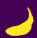
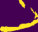

In [9]:
display_catalog(storms, 5)

Let's save our intermediate output.

In [10]:
storms.to_hdf('../output/data_products/storms_setting.h5', key='df')

/tmp/ipykernel_8462/701074315.py:1: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block5_values] [items->Index(['data_array'], dtype='str')]

  storms.to_hdf('../output/data_products/storms_setting.h5', key='df')


### Atmospheric Quantities

Now for the more interesting part, let's compute atmospheric characteristics and attributes for each storm. This includes things like their landfalling moisture content, wind speeds, as well as their impacts, like cumulative snowfall on the ice sheet or maximum surface temperature anomaly. In this tutorial, we will be focusing on gathering three quantities related to AR impacts: maxmimum surface temperature anomaly underneath the footprint over the AIS, cumulative snowfall on the AIS, and cumulative rainfall on the AIS.

We'll be using MERRA-2 reanalysis data to get these quantities. Of course, one might just execute this workflow by loading it up from disk at some local file system you have access to, but that's not very reproducible, accessible, or open! Instead, we'll be streaming MERRA-2 from AWS S3 buckets using `earthaccess`, a workflow that is much more reproducible, accessible, open, and lightweight!

:::{attention}

To access MERRA-2 data in the cloud, you'll need to first create a NASA Earthdata account and create the relevant [Earthdata prerequisite files](https://github.com/nasa/gesdisc-tutorials/blob/main/notebooks/How_to_Generate_Earthdata_Prerequisite_Files.ipynb), most notably the `.netrc` file with your Earthdata login credentials. You will also need to be in the AWS `us-west-2` region to stream from s3. If you are running this notebook on CryoCloud, you are in `us-west-2`.

:::

For this tutorial, we'll just be getting all of the variables from one MERRA-2 dataset. In our attempts with multiple datasets, we have found difficulties with the parallelization (hanging processes, etc.) So, we'll be demonstrating on a single dataset for now while we work out the kinks for using other datasets.

In [11]:
data_dois = {'climatology': '10.5067/5ESKGQTZG7FO',
             'T2M': '10.5067/3Z173KIE2TPD',
             'PRECIP': '10.5067/Q5GVUVUIVGO7'}

#### Climatology

To compute surface temperature anomaly, we'll need to compute a climatology. We'll compute the climatology of both of these variables via streaming first. The climatology is computed by taking monthly averaged dataset of our variables from MERRA-2, and then further averaging those across the years. Since the original Wille (2021) catalog on which ours is based goes from 1980 to 2022, we will be computing monthly averages over this range.

:::{attention}
Either we can run the next cell to create the climatology dataset, which should take about 20 minutes to do. Or, you could run this just once, save it, and just load it up from disk for future runs. If you don't want to wait, we've already stored it in the `/output/data_products/` directory of this repo, so you can skip this cell and run the next one.
:::

In [13]:
# grab granules for monthly data
granule_lst = earthaccess.search_data(doi=data_dois['climatology'], 
                                  temporal=('1980-01-01', '2022-12-31'))
# open pointers to nc4 stored in AWS S3 buckets
pointers = earthaccess.open(granule_lst, show_progress=False)

monthly_means = xr.open_mfdataset(pointers)
monthly_means = monthly_means[['T2M']]
climatology_ds = monthly_means.groupby(monthly_means.time.dt.month).mean().compute()
climatology_ds = climatology_ds.assign_coords(lat=climatology_ds.lat.round(5), lon=climatology_ds.lon.round(5))
climatology_ds.to_netcdf('output/data_products/climatology.nc4')

In [12]:
climatology_ds = xr.load_dataset('../output/data_products/climatology.nc4')

#### Streaming Setup

We will be streaming quantities from a MERRA-2 dataset and extracting summary statistics on a storm-by-storm basis, executing the loop by parallelizing using Ray. To ensure workers receive a roughly equal amount of work, we first sort the storms in order of decreasing duration, as storms with longer durations and larger spatiotemporal footprints require more time to compute their quantities.

In [13]:
sorted_storms = storms.sort_values(by='duration', ascending=False)

So each worker has a sufficient amount of work for each iteration of the parallel loop, we will also split the full list of storms into chunks of fixed size. Each worker will then take a chunk of storms to process. Below, we define global variables for how many workers and how many chunks we would like to use.

In [14]:
NUM_WORKERS = 4
CHUNK_SIZE = 10

The full streaming workflow may take a few hours to execute, depending on how many storms and how many quantities you are dealing with. We recommend using `jupyter-keepalive` to keep your Jupyter session alive even after exiting. Instructions on how to use this feature can be found [here](https://github.com/minrk/jupyter-keepalive). This functionality is already included in our image environment, so there is no need to install it. 

However, once you leave the notebook, even though the server is still alive and the computation is still running, output to track the computation will no longer be rendered in the notebook. To track the computation, we will set up a logger that will output the progress of our computations to `/output/logs/`.

In [15]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.StreamHandler(sys.stdout),
        logging.FileHandler('../output/logs/streaming_progress.log')
    ]
)
logging.info("Starting streaming workflow...")

2026-03-15 21:02:14,808 - INFO - Starting streaming workflow...


#### 2m-Temperature Anomaly

In our workflow, we go through each storm and execute a function called `compute_summaries` on each storm. `compute_summaries` computes scalar summaries of all desired variables from the particular MERRA-2 dataset we are
working with. To indicate which variables and which scalar summaries you would like, you must pass in a dictionary of dictionaries which we will call `func_vars_dict`. The keys of the outer dictionary are the variable names in the MERRA-2 dataset we'd like to compute aggregates of, and the values are themselves dictionaries where each item represents some desired aggregation function of that variable. The provided keys are the names of that scalar summary that will appear in the resulting dataset.

In this way, when we stream a set of days of data for a particular storm, we compute all relevant quantities on that storm before throwing the data away and re-streaming for the next storm.

First, we initialize our Ray cluster with the number of CPUs we wish to parallelize over, 1 worker per CPU. For each MERRA-2 dataset we stream from, we will be reinitializing and then closing the cluster. This is to reduce the memory footprint of the computation, ensuring a fresh start after each computation is complete.

In [16]:
ray.init(num_cpus=NUM_WORKERS, logging_level='ERROR', 
         _metrics_export_port=-1, include_dashboard=False, 
         log_to_driver=False, runtime_env={'py_modules': [artools.attribute_utils, artools.loading_utils]})

# put the climatologies and cell areas in the ray object store
climatology_ref = ray.put(climatology_ds)
cell_areas_ref = ray.put(cell_areas)
# prevents parallel open requests from being made to NASA servers
gatekeeper = EarthdataGatekeeper.remote()

/srv/conda/envs/notebook/lib/python3.12/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [17]:
func_vars_dict = {'T2M': {'max_T2M_anomaly_ais': lambda storm_da, var_da, area_da: 
                              compute_max_intensity(storm_da, var_da, area_da, ais_mask)}}

func_vars_dict_ref = ray.put(func_vars_dict)

data_doi = data_dois['T2M']
# list with the computed results
results_T2M = []

chunks = [sorted_storms[i:i + CHUNK_SIZE] for i in range(0, sorted_storms.shape[0], CHUNK_SIZE)]

logging.info(f"Starting T2M computations in chunks...")

chunk_refs = [ 
    compute_chunk_summaries.remote(
        chunk,
        func_vars_dict_ref,
        cell_areas_ref,
        data_doi,
        gatekeeper=gatekeeper,
        climatology_ds=climatology_ref
        ) for chunk in chunks ]

for j, ref in enumerate(chunk_refs):
    results = ray.get(ref)
    results_T2M.extend(results)
    # clean up the reference immediately so Ray empties the Object Store
    chunk_refs[j] = None    
    logging.info(f"T2M: Finished chunk {j + 1}/{len(chunks)}")

logging.info("T2M computations complete.")

2026-03-15 21:02:18,067 - INFO - Starting T2M computations in chunks...
2026-03-15 21:06:09,458 - INFO - T2M: Finished chunk 1/317
2026-03-15 21:06:09,460 - INFO - T2M: Finished chunk 2/317
2026-03-15 21:06:09,461 - INFO - T2M: Finished chunk 3/317
2026-03-15 21:06:09,462 - INFO - T2M: Finished chunk 4/317
2026-03-15 21:06:09,463 - INFO - T2M: Finished chunk 5/317
2026-03-15 21:06:09,464 - INFO - T2M: Finished chunk 6/317
2026-03-15 21:08:17,852 - INFO - T2M: Finished chunk 7/317
2026-03-15 21:08:17,854 - INFO - T2M: Finished chunk 8/317
2026-03-15 21:08:17,854 - INFO - T2M: Finished chunk 9/317
2026-03-15 21:08:28,594 - INFO - T2M: Finished chunk 10/317
2026-03-15 21:08:37,318 - INFO - T2M: Finished chunk 11/317
2026-03-15 21:08:53,857 - INFO - T2M: Finished chunk 12/317
2026-03-15 21:10:25,384 - INFO - T2M: Finished chunk 13/317
2026-03-15 21:10:26,209 - INFO - T2M: Finished chunk 14/317
2026-03-15 21:11:02,495 - INFO - T2M: Finished chunk 15/317
2026-03-15 21:11:02,496 - INFO - T2M:

In [18]:
# construct dataframe to concatenate into the original dataframe
labels = [key for quantity_dict in func_vars_dict.values() for key in quantity_dict.keys()]
df_T2M = pd.DataFrame(results_T2M, columns=labels, index=sorted_storms.index)
df_T2M_original_order = df_T2M.loc[storms.index]
df_T2M_original_order.to_csv('../output/data_products/results_T2M.csv')
logging.info("T2M results saved!")

2026-03-15 22:26:03,211 - INFO - T2M results saved!


In [19]:
ray.shutdown()

#### Snowfall and Rainfall

Snowfall and rainfall come from the same MERRA-2 dataset as poleward integrated vapor transport. However, we treat them separately because precipitation quantities are computed not on the spatiotemporal footprint of the mask as the previous quantities, but an augmented mask where even if the AR has left a pixel at a particular time, that pixel is still considered part of the AR footprint for the next 24 hours. Because of this extra preprocessing, we pass a `precip_func` function, the aggregation function we wish to use, into a summary computation function particular to this case (`compute_precip_summaries`).

In [20]:
ray.init(num_cpus=NUM_WORKERS, logging_level='ERROR', 
         _metrics_export_port=-1, include_dashboard=False, 
         log_to_driver=False, runtime_env={'py_modules': [artools.attribute_utils, artools.loading_utils]})

# put the climatologies and cell areas in the ray object store
climatology_ref = ray.put(climatology_ds)
cell_areas_ref = ray.put(cell_areas)
# prevents parallel open requests from being made to NASA servers
gatekeeper = EarthdataGatekeeper.remote()

In [21]:
data_doi = data_dois['PRECIP']

# storing the aggregation function for precip in the ray store
def precip_func(storm_da, var_da, area_da):
    return compute_cumulative(storm_da, var_da, area_da, ais_mask)
precip_func_ref = ray.put(precip_func)

In [ ]:
results_precip = []

chunks = [sorted_storms[i:i + CHUNK_SIZE] for i in range(0, sorted_storms.shape[0], CHUNK_SIZE)]

logging.info(f"Starting Precipitation computations in chunks...")

chunk_refs = [
        compute_precip_chunk_summaries.remote(
            chunk, 
            cell_areas_ref, 
            precip_func_ref,
            data_doi,
            gatekeeper=gatekeeper
        ) for chunk in chunks
    ]

for j, ref in enumerate(chunk_refs):
    results = ray.get(ref)
    results_precip.extend(results)
    # clean up the reference immediately so Ray empties the Object Store
    chunk_refs[j] = None    
    logging.info(f"Precip: Finished chunk {j + 1}/{len(chunks)}")

logging.info("Precipitation computations complete.")


2026-03-15 22:26:07,809 - INFO - Starting Precipitation computations in chunks...


In [ ]:
# construct dataframe to concatenate into the original dataframe
labels = ['cumulative_rainfall_ais', 'cumulative_snowfall_ais']
df_precip = pd.DataFrame(results_precip, columns=labels, index=sorted_storms.index)
df_precip_original_order = df_precip.loc[storms.index]
df_precip_original_order.to_csv('../output/data_products/results_precip.csv')
logging.info("Precip results saved!")

In [ ]:
ray.shutdown()

### Taking it all in

Let's take a look at all of our hard work! If you used `jupyter-keepalive` to execute this notebook, the variables with DataFrames will no longer be available for us to call up. Instead, let's load up all of the intermediate products we created along the way, concatenate, and view them!

In [1]:
# re-load the modules needed to load dataframes and display them
from artools.display_utils import display_catalog
import pandas as pd

In [2]:
storms_setting = pd.read_hdf('../output/data_products/storms_setting.h5')
storms_temp = pd.read_csv('../output/data_products/results_T2M.csv', index_col='cluster')
storms_precip = pd.read_csv('../output/data_products/results_precip.csv', index_col='cluster')

In [3]:
full_df = pd.concat([storms_setting, storms_temp, storms_precip], axis=1)

,data_array,is_landfalling,max_area,mean_landfalling_area,cumulative_landfalling_area,duration,start_date,end_date,max_south_extent,region,max_T2M_anomaly_ais,cumulative_rainfall_ais,cumulative_snowfall_ais
cluster,,,,,,,,,,,,,
1,,True,1906980,14234,26690,45,1980-01-02 00:00:00,1980-01-03 18:00:00,-74.500000,West,4.733398,9919352615.151731,513832211595.101501
4,,True,1755659,190118,332707,42,1980-01-06 18:00:00,1980-01-08 12:00:00,-74.000000,East 2,9.100540,129040651265.628204,5615619341039.955078
5,,True,83382,83382,10422,3,1980-01-08 12:00:00,1980-01-08 12:00:00,-79.500000,East 1,7.766602,0.000000,33919749951.568169
6,,True,1429138,1429138,178642,3,1980-01-09 15:00:00,1980-01-09 15:00:00,-83.500000,East 2,11.666794,0.000000,1003073258925.341431
11,,True,735749,210763,52690,6,1980-01-11 12:00:00,1980-01-11 15:00:00,-85.000000,West,4.731720,12069321713.940012,1077243106042.640747
12,,True,1466805,119788,149735,30,1980-01-12 03:00:00,1980-01-13 09:00:00,-85.000000,East 2,8.239502,25478260652.503857,2532361154585.029297
13,,True,2564243,1069995,1604992,36,1980-01-14 12:00:00,1980-01-16 09:00:00,-85.000000,East 1,12.359955,407576625736.306702,14686205534056.236328
14,,True,1919206,980,857,21,1980-01-17 06:00:00,1980-01-18 00:00:00,-69.500000,East 1,3.037811,5568667.258710,68490101610.577286
16,,True,2525372,224373,532885,57,1980-01-17 12:00:00,1980-01-19 18:00:00,-85.000000,East 2,8.477936,2158083220.805957,2365481510314.201172

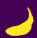
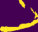
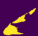
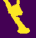
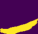

In [4]:
display_catalog(full_df, 10)